INTRODUCCIÓN

El objetivo de esta práctica es implementar, evaluar y optimizar distintos algoritmos de Machine Learning para resolver un problema de regresión utilizando el dataset Steel Industry Energy Consumption.

A lo largo del proyecto se realizaron diferentes etapas, incluyendo el análisis exploratorio de datos (EDA), la implementación de modelos base y la optimización mediante herramientas de Inteligencia Artificial Generativa y GridSearchCV.

In [1]:
# Librerías para análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Modelos
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Escalado para SVR
from sklearn.preprocessing import StandardScaler

# XGBoost
from xgboost import XGBRegressor

# Tiempo de ejecución
import time

In [2]:
# Subir dataset
from google.colab import files
uploaded = files.upload()

# Cargar dataset
import pandas as pd
df = pd.read_csv("Steel_industry_data.csv")

df.head()

Saving Steel_industry_data.csv to Steel_industry_data (1).csv


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [3]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

,0
date,0
Usage_kWh,0
Lagging_Current_Reactive.Power_kVarh,0
Leading_Current_Reactive_Power_kVarh,0
CO2(tCO2),0
Lagging_Current_Power_Factor,0
Leading_Current_Power_Factor,0
NSM,0
WeekStatus,0
Day_of_week,0


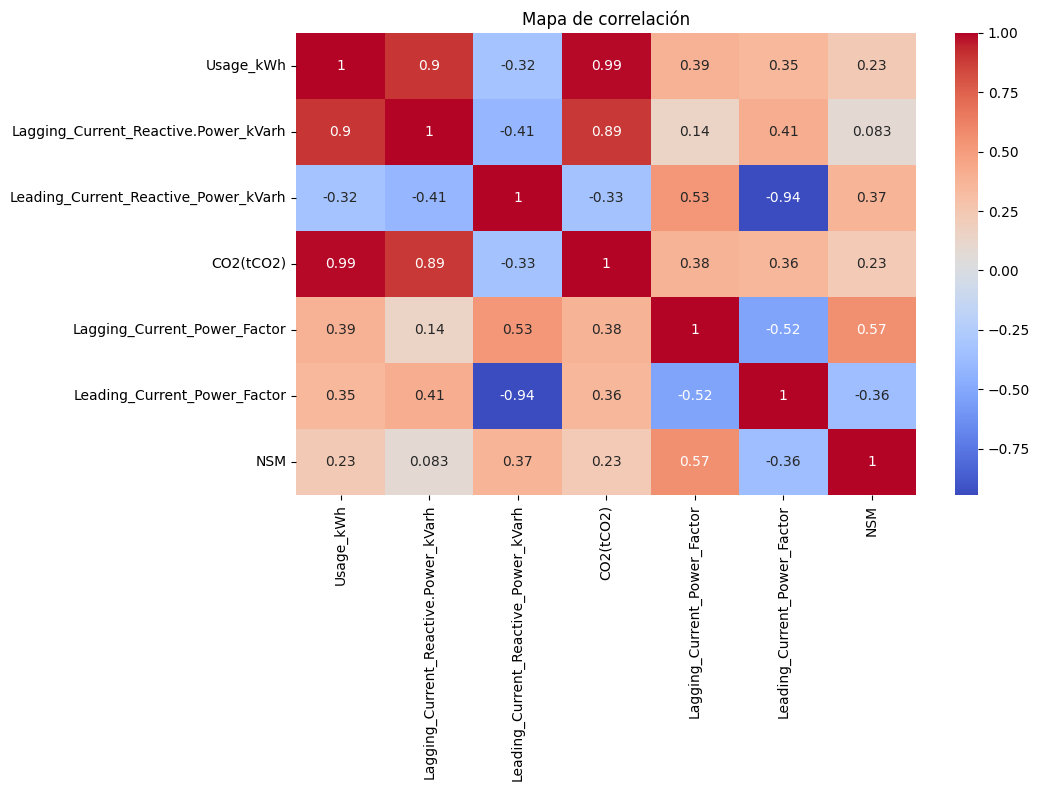

In [4]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Mapa de correlación")
plt.show()

In [5]:
# eliminar fecha
df = df.drop("date", axis=1)

# convertir categóricas
df = pd.get_dummies(df, drop_first=True)

# separar variables
X = df.drop("Usage_kWh", axis=1)
y = df["Usage_kWh"]

# dividir dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Modelos

In [19]:
#Evaluación de modelos
import time
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def evaluar_modelo(modelo, X_train, X_test, y_train, y_test):

    inicio = time.time()

    modelo.fit(X_train, y_train)

    fin = time.time()

    pred = modelo.predict(X_test)

    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    tiempo_ms = (fin - inicio) * 1000

    return r2, mae, rmse, tiempo_ms

In [20]:
#Regresion lineal
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

r2_lr, mae_lr, rmse_lr, t_lr = evaluar_modelo(lr, X_train, X_test, y_train, y_test)

In [21]:
#Arbol de Decisión
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

r2_dt, mae_dt, rmse_dt, t_dt = evaluar_modelo(dt, X_train, X_test, y_train, y_test)

In [22]:
#Ramdom Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

r2_rf, mae_rf, rmse_rf, t_rf = evaluar_modelo(rf, X_train, X_test, y_train, y_test)

In [23]:
#SVR
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr = SVR()

r2_svr, mae_svr, rmse_svr, t_svr = evaluar_modelo(
    svr, X_train_scaled, X_test_scaled, y_train, y_test
)

In [24]:
#XGBoost
from xgboost import XGBRegressor

xgb = XGBRegressor()

r2_xgb, mae_xgb, rmse_xgb, t_xgb = evaluar_modelo(
    xgb, X_train, X_test, y_train, y_test
)

In [25]:
resultados = pd.DataFrame({
    "Modelo": ["Linear Regression","Decision Tree","Random Forest","SVR","XGBoost"],
    "R2": [r2_lr, r2_dt, r2_rf, r2_svr, r2_xgb],
    "MAE": [mae_lr, mae_dt, mae_rf, mae_svr, mae_xgb],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf, rmse_svr, rmse_xgb],
    "Tiempo": [t_lr, t_dt, t_rf, t_svr, t_xgb]
})

resultados

,Modelo,R2,MAE,RMSE,Tiempo
0,Linear Regression,0.984304,2.533774,4.224012,70.066452
1,Decision Tree,0.998075,0.524426,1.479274,240.558624
2,Random Forest,0.998985,0.335275,1.074138,16200.793266
3,SVR,0.988896,1.815656,3.552781,40585.457802
4,XGBoost,0.999093,0.473556,1.015194,307.470083


Pregunta a la IA

¿Qué ajustes de hiperparámetros o transformaciones de datos se recomiendan para mejorar el rendimiento de modelos de regresión en el dataset Steel Industry Energy Consumption?

Respuesta sugerida

Para mejorar el rendimiento de los modelos de regresión en el dataset Steel Industry Energy Consumption, se pueden aplicar las siguientes transformaciones de datos y ajustes de hiperparámetros:

1️⃣ Transformaciones de datos

Escalado de variables

Modelos como Support Vector Regression (SVR) son sensibles a la escala de los datos, por lo que se recomienda aplicar StandardScaler o MinMaxScaler a las variables numéricas.

Codificación de variables categóricas

Las variables categóricas como:

WeekStatus

Day_of_week

Load_Type

deben transformarse mediante One-Hot Encoding utilizando pd.get_dummies() para que los modelos de Machine Learning puedan procesarlas.

Eliminación de variables irrelevantes

La variable date puede eliminarse o transformarse en variables derivadas (hora, día o mes), ya que su formato original no es útil directamente para los modelos de regresión.

2️⃣ Ajustes de hiperparámetros sugeridos
Random Forest Regressor

Los hiperparámetros que pueden mejorar el rendimiento incluyen:

n_estimators (número de árboles): 100 – 300

max_depth (profundidad máxima del árbol): 10 – 20

min_samples_split: 2 – 5

min_samples_leaf: 1 – 2

Estos parámetros ayudan a controlar el sobreajuste y mejorar la capacidad de generalización del modelo.

Support Vector Regression (SVR)

Los hiperparámetros recomendados para optimizar son:

C (regularización): 1 – 100

epsilon: 0.1 – 0.5

kernel: "rbf"

Estos parámetros influyen en la flexibilidad del modelo y el margen de error permitido.

XGBoost Regressor

Los hiperparámetros más importantes incluyen:

n_estimators: 100 – 300

learning_rate: 0.01 – 0.1

max_depth: 3 – 8

subsample: 0.8 – 1.0

Estos parámetros permiten mejorar la precisión del modelo y evitar el sobreajuste.

💡 Interpretación para tu práctica

Estas recomendaciones permiten optimizar el rendimiento de los modelos de regresión, ya que ajustan la complejidad de los algoritmos y mejoran el preprocesamiento de los datos, lo cual puede reflejarse en mejores métricas como R², MAE y RMSE.

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Mejores parámetros:", grid_rf.best_params_)

Mejores parámetros: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [27]:
best_rf = grid_rf.best_estimator_

r2_rf_g, mae_rf_g, rmse_rf_g, t_rf_g = evaluar_modelo(
    best_rf, X_train, X_test, y_train, y_test
)

print("R2:", r2_rf_g)
print("MAE:", mae_rf_g)
print("RMSE:", rmse_rf_g)

R2: 0.9989523530984689
MAE: 0.34263939602622945
RMSE: 1.091276149789215


In [28]:
from xgboost import XGBRegressor

param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1]
}

grid_xgb = GridSearchCV(
    XGBRegressor(objective="reg:squarederror"),
    param_grid_xgb,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Mejores parámetros:", grid_xgb.best_params_)

Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


In [29]:
best_xgb = grid_xgb.best_estimator_

r2_xgb_g, mae_xgb_g, rmse_xgb_g, t_xgb_g = evaluar_modelo(
    best_xgb, X_train, X_test, y_train, y_test
)

print("R2:", r2_xgb_g)
print("MAE:", mae_xgb_g)
print("RMSE:", rmse_xgb_g)

R2: 0.9991107105789925
MAE: 0.4143532453348103
RMSE: 1.0054228710495783


In [30]:
resultados_finales = pd.DataFrame({
    "Modelo":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "SVR",
        "XGBoost",
        "Random Forest GridSearch",
        "XGBoost GridSearch"
    ],

    "R2":[
        r2_lr,
        r2_dt,
        r2_rf,
        r2_svr,
        r2_xgb,
        r2_rf_g,
        r2_xgb_g
    ],

    "MAE":[
        mae_lr,
        mae_dt,
        mae_rf,
        mae_svr,
        mae_xgb,
        mae_rf_g,
        mae_xgb_g
    ],

    "RMSE":[
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_svr,
        rmse_xgb,
        rmse_rf_g,
        rmse_xgb_g
    ]
})

resultados_finales

,Modelo,R2,MAE,RMSE
0,Linear Regression,0.984304,2.533774,4.224012
1,Decision Tree,0.998075,0.524426,1.479274
2,Random Forest,0.998985,0.335275,1.074138
3,SVR,0.988896,1.815656,3.552781
4,XGBoost,0.999093,0.473556,1.015194
5,Random Forest GridSearch,0.998952,0.342639,1.091276
6,XGBoost GridSearch,0.999111,0.414353,1.005423


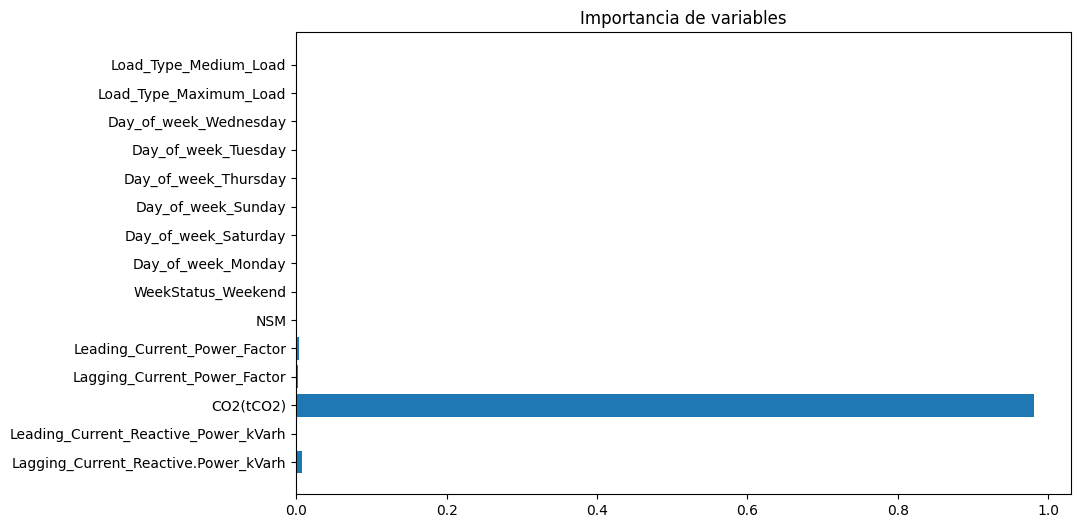

In [31]:
#Gráfica para ubicar las variables que tienen más relevancia para identificar el modelo ganador
import matplotlib.pyplot as plt

importances = best_xgb.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Importancia de variables")
plt.show()

El modelo XGBoost obtuvo el mejor desempeño con un R² de 0.99911, lo que indica que el modelo logra explicar aproximadamente el 99.9% de la variabilidad en el consumo energético.

Este alto nivel de precisión puede atribuirse a la fuerte relación existente entre las variables del dataset, como la potencia reactiva, el factor de potencia y las emisiones de CO₂, las cuales están directamente relacionadas con el consumo eléctrico en la industria del acero.

Además, el algoritmo XGBoost es especialmente eficaz para capturar relaciones no lineales entre variables, lo que le permite generar predicciones altamente precisas en este tipo de problemas de regresión.

Conclusión

En esta práctica se implementaron y compararon distintos algoritmos de Machine Learning para regresión con el objetivo de predecir el consumo energético (Usage_kWh) en la industria del acero a partir del dataset Steel Industry Energy Consumption. Para ello se realizaron diferentes fases que incluyeron el análisis exploratorio de datos (EDA), la implementación de modelos base y la optimización de hiperparámetros.

A partir de los resultados obtenidos, el modelo XGBoost Regressor presentó el mejor desempeño, alcanzando un R² de 0.99911, lo que indica que el modelo es capaz de explicar aproximadamente el 99.9% de la variabilidad del consumo energético. Este alto nivel de precisión se debe a que el algoritmo XGBoost utiliza un enfoque de boosting basado en árboles de decisión, lo que le permite capturar relaciones complejas y no lineales entre las variables del dataset. Además, varias de las variables presentes en los datos, como la potencia reactiva y el factor de potencia, tienen una relación directa con el consumo eléctrico, lo que favorece la capacidad predictiva del modelo.

El uso de Inteligencia Artificial Generativa (IAG) resultó útil durante la fase de optimización, ya que permitió identificar los hiperparámetros más relevantes para ajustar en los modelos, como n_estimators, max_depth y learning_rate. Esto facilitó el proceso de configuración del GridSearchCV, permitiendo encontrar combinaciones de parámetros más adecuadas para mejorar el rendimiento de los algoritmos evaluados.

Finalmente, se observó que existe una relación entre el tiempo de ejecución y la precisión de los modelos. Algoritmos más complejos como Random Forest y XGBoost requirieron mayor tiempo de entrenamiento en comparación con modelos más simples como la Regresión Lineal, sin embargo, también ofrecieron una mayor capacidad de predicción. Esto demuestra que, en problemas de regresión con datos complejos, los modelos más avanzados pueden justificar su mayor costo computacional al proporcionar resultados significativamente más precisos.

En conclusión, el modelo XGBoost (desde un principio la IA predijo que, para este tipo de modelos, el XGBoost suele ser el más optimo, y en está practica no fue la excepción) optimizado resultó ser la mejor opción para este dataset, ya que combina una alta capacidad de predicción con una buena adaptación a las características del problema de consumo energético industrial.